In [1]:
import os
import time
import torch
import librosa
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
import librosa.display

from transformers import WhisperProcessor
from transformers import WhisperForConditionalGeneration

from jiwer import wer
from jiwer import cer

In [2]:
DATASET_PATH=r"LibriSpeech\dev-clean-2"

In [4]:
# Reading All audio files and transcript
audio_files=[]
transcripts=[]

for speaker in os.listdir(DATASET_PATH):
    speaker_path=os.path.join(DATASET_PATH,speaker)
    if not os.path.isdir(speaker_path):
        continue
    for chapter in os.listdir(speaker_path):
        chapter_path=os.path.join(speaker_path,chapter)
        if not os.path.isdir(chapter_path):
            continue
        transcript_file=None
        for file in os.listdir(chapter_path):

            if file.endswith(".trans.txt"):
                transcript_file=os.path.join(chapter_path,file)
        transcript_dict={}
        with open(transcript_file,"r",encoding="utf-8") as f:
            for line in f:
                parts=line.strip().split(" ",1)
                transcript_dict[parts[0]]=parts[1]

        for file in os.listdir(chapter_path):
            if file.endswith(".flac"):
                path=os.path.join(chapter_path,file)
                file_id=file.replace(".flac","")
                audio_files.append(path)
                transcripts.append(transcript_dict[file_id])

In [5]:
# Create DataFrame
df=pd.DataFrame({"Audio":audio_files,"Transcript":transcripts})

df.head()

,Audio,Transcript
0,LibriSpeech\dev-clean-2\1272\135031\1272-13503...,BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERIN...
1,LibriSpeech\dev-clean-2\1272\135031\1272-13503...,HE HAS GONE AND GONE FOR GOOD ANSWERED POLYCHR...
2,LibriSpeech\dev-clean-2\1272\135031\1272-13503...,I HAVE REMAINED A PRISONER ONLY BECAUSE I WISH...
3,LibriSpeech\dev-clean-2\1272\135031\1272-13503...,THE LITTLE GIRL HAD BEEN ASLEEP BUT SHE HEARD ...
4,LibriSpeech\dev-clean-2\1272\135031\1272-13503...,THE KING HAS FLED IN DISGRACE AND YOUR FRIENDS...


In [6]:
print("Total Audio Files:",len(df))
durations=[]
for file in df["Audio"]:
    y,sr=librosa.load(file,sr=None)
    durations.append(len(y)/sr)
print("Average Duration:",round(sum(durations)/len(durations),2),"seconds")
print("Sample Rate:",sr)

Total Audio Files: 1089
Average Duration: 6.73 seconds
Sample Rate: 16000


In [7]:
# Sample Audio
sample_path=df["Audio"].iloc[0]
sample_text=df["Transcript"].iloc[0]
print(sample_text)

BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERING THE LOVELY ROSE PRINCESS HAS BECOME A FIDDLE WITHOUT A BOW WHILE POOR SHAGGY SITS THERE A COOING DOVE


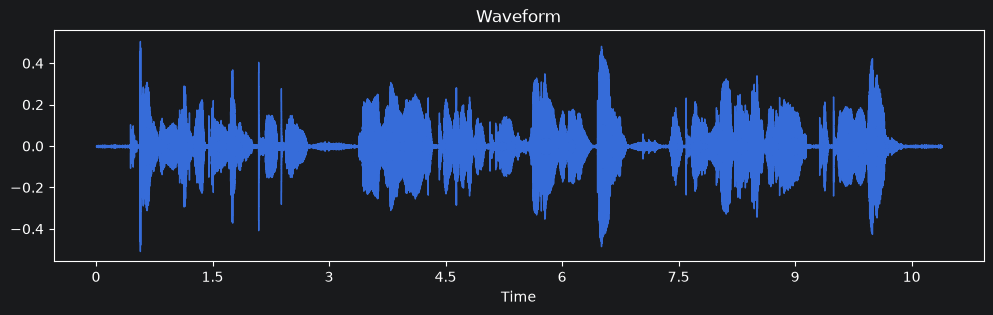

In [8]:
y,sr=librosa.load(sample_path,sr=None)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y,sr=sr)
plt.title("Waveform")
plt.show()

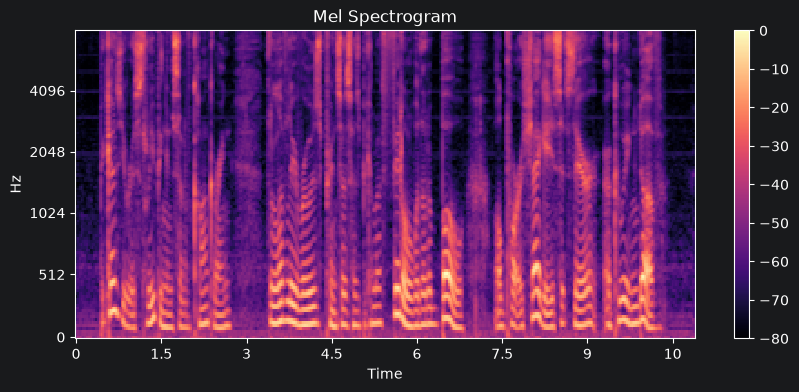

In [10]:
import numpy as np
mel=librosa.feature.melspectrogram(y=y,sr=sr)
mel_db=librosa.power_to_db(mel,ref=np.max)
plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db,sr=sr,x_axis="time",y_axis="mel")
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [11]:
#Load whisper Model
processor=WhisperProcessor.from_pretrained("openai/whisper-tiny")

model=WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=model.to(device)
model.eval()
print(device)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MADHUMITA\.cache\huggingface\hub\models--openai--whisper-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

cpu


In [12]:
# Audio Preprocessing Function
def load_audio(path):
    audio,sr=librosa.load(
        path,
        sr=16000,
        mono=True
    )
    return audio

In [13]:
# Transcript function
def transcribe(audio_path):
    audio=load_audio(audio_path)
    inputs=processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )
    input_features=inputs.input_features.to(device)
    start=time.time()
    with torch.no_grad():
        predicted_ids=model.generate(input_features)
    inference_time=time.time()-start
    transcription=processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]
    return transcription,inference_time

In [15]:
ground_truth=[]
predictions=[]
times=[]
for i in range(20):
    pred,t=transcribe(df["Audio"].iloc[i])
    ground_truth.append(df["Transcript"].iloc[i])
    predictions.append(pred)
    times.append(t)

In [16]:
results=pd.DataFrame({
    "Ground Truth":ground_truth,
    "Prediction":predictions,
    "Inference Time":times
})

results.head()

,Ground Truth,Prediction,Inference Time
0,BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERIN...,"Because you are asleep instead of conquering,...",3.289787
1,HE HAS GONE AND GONE FOR GOOD ANSWERED POLYCHR...,He has gone and gone for good answered Paul I...,1.408683
2,I HAVE REMAINED A PRISONER ONLY BECAUSE I WISH...,I have remained a prisoner only because I wis...,1.448691
3,THE LITTLE GIRL HAD BEEN ASLEEP BUT SHE HEARD ...,"The little girl had been asleep, but she hear...",0.855831
4,THE KING HAS FLED IN DISGRACE AND YOUR FRIENDS...,The king is flooded disgrace and your friends...,0.772033


In [19]:
wer_score=wer(ground_truth,predictions)
print("WER:",wer_score)
cer_score=cer(ground_truth,predictions)
print("CER:",cer_score)
avg_time=sum(times)/len(times)
print("Average Inference Time:",round(avg_time,3),"seconds")

torch.save(
    model.state_dict(),
    "whisper_full.pth"
)
model_size=os.path.getsize("whisper_full.pth")/(1024*1024)
print("Model Size:",round(model_size,2),"MB")

WER: 1.0229885057471264
CER: 0.8479228486646885
Average Inference Time: 0.986 seconds
Model Size: 144.1 MB


In [20]:
for i in range(5):
    print("="*60)
    print("Ground Truth:")
    print(ground_truth[i])
    print()
    print("Prediction:")
    print(predictions[i])
    print()
    print("Inference Time:",round(times[i],3),"seconds")

Ground Truth:
BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERING THE LOVELY ROSE PRINCESS HAS BECOME A FIDDLE WITHOUT A BOW WHILE POOR SHAGGY SITS THERE A COOING DOVE

Prediction:
 Because you are asleep instead of conquering, the lovely Rose Princess has become a fiddle without a bow. While poor Shaggy sits there, a cooling dove.

Inference Time: 3.29 seconds
Ground Truth:
HE HAS GONE AND GONE FOR GOOD ANSWERED POLYCHROME WHO HAD MANAGED TO SQUEEZE INTO THE ROOM BESIDE THE DRAGON AND HAD WITNESSED THE OCCURRENCES WITH MUCH INTEREST

Prediction:
 He has gone and gone for good answered Paul Icrom who had managed to squeeze into the room beside the dragon and had witnessed the occurrences with much interest.

Inference Time: 1.409 seconds
Ground Truth:
I HAVE REMAINED A PRISONER ONLY BECAUSE I WISHED TO BE ONE AND WITH THIS HE STEPPED FORWARD AND BURST THE STOUT CHAINS AS EASILY AS IF THEY HAD BEEN THREADS

Prediction:
 I have remained a prisoner only because I wished to be one. And with th

In [21]:
import copy
quantized_model=copy.deepcopy(model)
quantized_model=quantized_model.cpu()
quantized_model=torch.quantization.quantize_dynamic(
    quantized_model,
    {torch.nn.Linear},
    dtype=torch.qint8
)
quantized_model.eval()
print("Quantized model created successfully.")

C:\Users\MADHUMITA\AppData\Local\Temp\ipykernel_26700\636440729.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model=torch.quantization.quantize_dynamic(
D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\torch\ao\nn\quantized\modules\utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creatio

Quantized model created successfully.


In [22]:
# Quantized transcript function
def transcribe_quantized(audio_path):
    audio=load_audio(audio_path)
    inputs=processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )
    input_features=inputs.input_features
    start=time.time()
    with torch.no_grad():
        predicted_ids=quantized_model.generate(input_features)
    inference_time=time.time()-start
    transcription=processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]
    return transcription,inference_time

In [23]:
predictions_q=[]
times_q=[]
for i in range(20):
    pred,t=transcribe_quantized(df["Audio"].iloc[i])
    predictions_q.append(pred)
    times_q.append(t)

In [24]:
wer_q=wer(
    ground_truth,
    predictions_q
)
print("Quantized WER:",wer_q)

Quantized WER: 1.0459770114942528


In [25]:
cer_q=cer(
    ground_truth,
    predictions_q
)
print("Quantized CER:",cer_q)

avg_time_q=sum(times_q)/len(times_q)
print("Average Quantized Inference Time:",round(avg_time_q,3),"seconds")

torch.save(
    quantized_model.state_dict(),
    "whisper_quantized.pth"
)
quantized_size=os.path.getsize("whisper_quantized.pth")/(1024*1024)
print("Quantized Model Size:",round(quantized_size,2),"MB")

Quantized CER: 0.8946587537091988
Average Quantized Inference Time: 0.873 seconds
Quantized Model Size: 115.9 MB


In [26]:
comparison=pd.DataFrame({
    "Ground Truth":ground_truth,
    "Full Model":predictions,
    "Quantized Model":predictions_q
})

comparison.head(10)

,Ground Truth,Full Model,Quantized Model
0,BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERIN...,"Because you are asleep instead of conquering,...",Because you're sleeping instead of conquering...
1,HE HAS GONE AND GONE FOR GOOD ANSWERED POLYCHR...,He has gone and gone for good answered Paul I...,He has gone and gone for good. Answered polyc...
2,I HAVE REMAINED A PRISONER ONLY BECAUSE I WISH...,I have remained a prisoner only because I wis...,I have remained in the prisoner only because ...
3,THE LITTLE GIRL HAD BEEN ASLEEP BUT SHE HEARD ...,"The little girl had been asleep, but she hear...","the little girl had been asleep, but she had ..."
4,THE KING HAS FLED IN DISGRACE AND YOUR FRIENDS...,The king is flooded disgrace and your friends...,The king is flooded with disgrace and your fr...
5,I BEGGED RUGGEDO LONG AGO TO SEND HIM AWAY BUT...,"I begged Ruggano a long ago to send him away,...","I'm being regular long ago, it's something wr..."
6,I ALSO OFFERED TO HELP YOUR BROTHER TO ESCAPE ...,I also offered to help your brother to escape...,I also offered to help you run into this. Kee...
7,HE EATS AND SLEEPS VERY STEADILY REPLIED THE N...,"It eats and sleeps very steadily, replied the...",it's a very steadily replayed new king.
8,I HOPE HE DOESN'T WORK TOO HARD SAID SHAGGY,I hope he doesn't work too hard since she got...,I hope you don't work too hard.
9,HE DOESN'T WORK AT ALL,He doesn't work at all.,He doesn't work at all.


In [27]:
comparison_metrics=pd.DataFrame({
    "Metric":[
        "WER",
        "CER",
        "Average Inference Time (s)",
        "Model Size (MB)"
    ],
    "Full Model":[
        wer_score,
        cer_score,
        avg_time,
        model_size
    ],
    "Quantized Model":[
        wer_q,
        cer_q,
        avg_time_q,
        quantized_size
    ]
})

comparison_metrics

,Metric,Full Model,Quantized Model
0,WER,1.022989,1.045977
1,CER,0.847923,0.894659
2,Average Inference Time (s),0.985888,0.873093
3,Model Size (MB),144.104753,115.898875


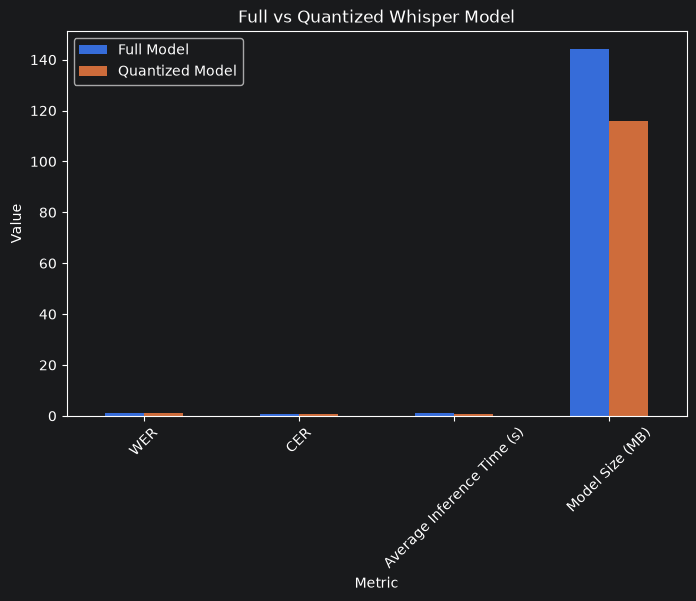

In [28]:
comparison_plot=comparison_metrics.set_index("Metric")
comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)
plt.ylabel("Value")
plt.title("Full vs Quantized Whisper Model")

plt.xticks(rotation=45)
plt.show()

In [29]:
for i in range(5):
    print("="*70)
    print("Ground Truth:")
    print(ground_truth[i])
    print()
    print("Full Model:")
    print(predictions[i])
    print()
    print("Quantized Model:")
    print(predictions_q[i])
    print()

Ground Truth:
BECAUSE YOU WERE SLEEPING INSTEAD OF CONQUERING THE LOVELY ROSE PRINCESS HAS BECOME A FIDDLE WITHOUT A BOW WHILE POOR SHAGGY SITS THERE A COOING DOVE

Full Model:
 Because you are asleep instead of conquering, the lovely Rose Princess has become a fiddle without a bow. While poor Shaggy sits there, a cooling dove.

Quantized Model:
 Because you're sleeping instead of conquering, the lovely rose princess has become a fiddle without a bow. Before a shaggy sits there, or cooling enough.

Ground Truth:
HE HAS GONE AND GONE FOR GOOD ANSWERED POLYCHROME WHO HAD MANAGED TO SQUEEZE INTO THE ROOM BESIDE THE DRAGON AND HAD WITNESSED THE OCCURRENCES WITH MUCH INTEREST

Full Model:
 He has gone and gone for good answered Paul Icrom who had managed to squeeze into the room beside the dragon and had witnessed the occurrences with much interest.

Quantized Model:
 He has gone and gone for good. Answered polychrome, who had managed to squeeze into the room beside the dragon, and had witn

1. Both models produced highly similar transcriptions on the selected audio samples.
2. The quantized model occasionally substituted or omitted a few words, leading to a slight increase in WER and CER.
3. Despite the small reduction in transcription quality, the quantized model required less storage and achieved faster inference on the CPU.